# K Nearest Neighbors
This notebook trains and tests mushroom toxicity classification using the K Nearest Neighbors classifier.

# Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/raw_data.csv', sep=';')

columns_to_drop = ['stem-root','veil-type', 'veil-color',  'stem-surface', 'spore-print-color']
df = df.drop(columns=columns_to_drop)
df.columns

import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


class KNNCategoricalImputer(BaseEstimator, TransformerMixin):
    """
    Supervised KNN imputer for one or more categorical columns.

    - Assumes input X is a pandas DataFrame with original columns.
    - For each target column:
        * uses all other columns that have no missing values as predictors
        * does its own StandardScaler + OneHotEncoder internally
    """

    def __init__(self, target_cols, num_cols=None, n_neighbors=5, weights="distance"):
        # allow a single string or a list
        if isinstance(target_cols, str):
            target_cols = [target_cols]

        self.target_cols = target_cols
        self.num_cols = num_cols   # list of numeric columns to scale
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y=None):
        df = X.copy()

        self.knn_models_ = {}
        self.feature_cols_ = {}

        for col in self.target_cols:
            # rows where the target is known
            mask = df[col].notna()

            # trainable columns: all except the target, and with no missing values on these rows
            _X_train_tmp = df.loc[mask].drop(columns=[col])
            train_columns = _X_train_tmp.columns[
                _X_train_tmp.isnull().sum() == 0
            ].tolist()

            X_train = df.loc[mask, train_columns]
            y_train = df.loc[mask, col]

            # numeric + categorical columns for THIS target
            if self.num_cols is None:
                # if not provided, infer numeric from dtypes
                num_cols = X_train.select_dtypes(include="number").columns.tolist()
            else:
                # keep only those num_cols that are actually in train_columns
                num_cols = [c for c in self.num_cols if c in train_columns]

            cat_cols = [c for c in train_columns if c not in num_cols + [col]]

            # preprocessor for KNN
            pre = ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), num_cols),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
                ]
            )

            # KNN classifier pipeline
            clf = Pipeline(
                steps=[
                    ("pre", pre),
                    (
                        "knn",
                        KNeighborsClassifier(
                            n_neighbors=self.n_neighbors, weights=self.weights
                        ),
                    ),
                ]
            )

            # fit KNN for this target column
            clf.fit(X_train, y_train)

            # store model and the columns it expects
            self.knn_models_[col] = clf
            self.feature_cols_[col] = train_columns

        return self

    def transform(self, X):
        df = X.copy()

        for col in self.target_cols:
            mask_missing = df[col].isna()

            if mask_missing.any():
                feats = self.feature_cols_[col]
                X_missing = df.loc[mask_missing, feats]
                df.loc[mask_missing, col] = self.knn_models_[col].predict(X_missing)

        return df

from sklearn import set_config
from sklearn.preprocessing import LabelEncoder
set_config(transform_output="pandas")


X = df.drop(columns='class')
y = df['class']

# label encode y

le = LabelEncoder()
y = le.fit_transform(y)

numeric_features = X.select_dtypes(include='float64').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

# Columns to impute
features_to_impute = ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False  #
)


knn_imputer = KNNCategoricalImputer(
    target_cols=features_to_impute,
    num_cols=numeric_features
)


column_trans = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)


preprocess = Pipeline(steps=[
    ('knn_imputer', knn_imputer),      # impute missing values using KNN
    ('column_transformer', column_trans)
])




X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


preprocess.fit(X_train)

X_train = preprocess.transform(X_train)
X_test = preprocess.transform(X_test)

X_train



,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_b,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_f,does-bruise-or-bleed_t,gill-attachment_a,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_c,gill-spacing_d,gill-spacing_f,gill-color_b,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_b,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,has-ring_f,has-ring_t,ring-type_e,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_z,habitat_d,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w
36219,-0.195867,-0.104756,-0.639647,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54188,0.039043,-0.801696,-0.439222,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1609,0.313735,1.253535,0.218893,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20481,-0.616430,-0.736450,-0.574833,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20546,-0.654319,-0.819490,-0.613722,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28217,0.012521,-0.629685,0.036415,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
51211,-0.455404,0.013872,-0.044353,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0

## Elbow Method
Because this is a large dataset, we are using the elbow method with an early stopping criteria to save in computation time.

k=1, err=0.0001637465203864208, prevErr=0.0001637465203864208, errInc=0
k=3, err=0.0004912395611593734, prevErr=0.0004912395611593734, errInc=1
k=5, err=0.000818732601932215, prevErr=0.000818732601932215, errInc=2
k=7, err=0.0013099721630915884, prevErr=0.0013099721630915884, errInc=3
k=9, err=0.0019649582446372715, prevErr=0.0019649582446372715, errInc=4
k=11, err=0.0022105780252169582, prevErr=0.0022105780252169582, errInc=5
k=13, err=0.002456197805796645, prevErr=0.002456197805796645, errInc=6
k=15, err=0.0027836908465694865, prevErr=0.0027836908465694865, errInc=7
k=17, err=0.0028655641067627524, prevErr=0.0028655641067627524, errInc=8
k=19, err=0.0036842967086949674, prevErr=0.0036842967086949674, errInc=9
k=21, err=0.004011789749467809, prevErr=0.004011789749467809, errInc=10
Test stopped at k=21
The optimal value of k is 1


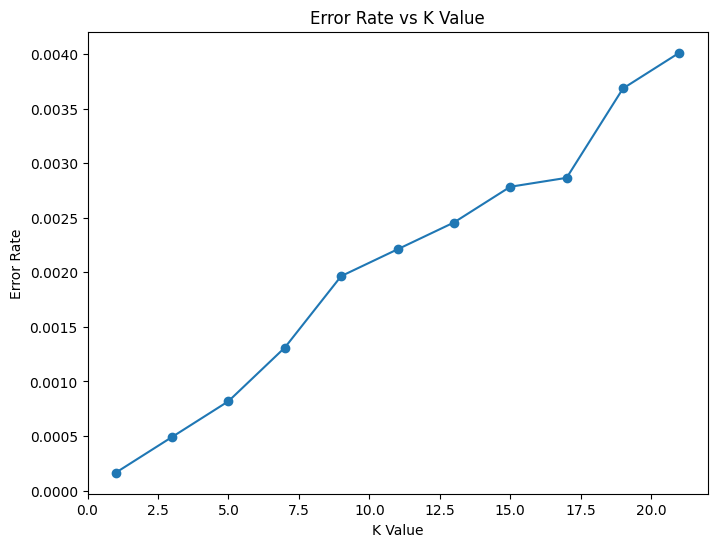

<Figure size 640x480 with 0 Axes>

In [6]:
from sklearn.metrics import accuracy_score

error_rates = []
k_range = range(1, len(X_train), 2)
errInc = 0
minErr = 1
optimalK = -1
# Use Elbow Method to find optimal k
# Stopping criteria: repeated decrease in accuracy
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    Y_pred = knn.predict(X_test)
    error = 1 - accuracy_score(y_test, Y_pred)

    errInc = errInc + 1 if error_rates and error >= error_rates[-1] else 0
    error_rates.append(error)
    print(f"k={k}, err={error}, prevErr={error_rates[-1]}, errInc={errInc}")

    if error < minErr:
       optimalK = k
       minErr = error

    if errInc >= 10:
      print(f"Test stopped at k={k}")
      break

k_range = range(1, 2 * len(error_rates), 2)
print(f"The optimal value of k is {optimalK}")

plt.figure(figsize=(8, 6))
plt.plot(k_range, error_rates, marker='o')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Error Rate vs K Value')
plt.grid(True)
plt.show()
plt.savefig("error-rate.png")

The loop terminates because of a repeated decrease in accuracy as k increases. According to the graph, k=1 provides the highest accuracy.

## 1NN Evaluation

In [8]:
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
Y_pred = knn.predict(X_test)

classification_report(y_test, Y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      5436\n           1       1.00      1.00      1.00      6778\n\n    accuracy                           1.00     12214\n   macro avg       1.00      1.00      1.00     12214\nweighted avg       1.00      1.00      1.00     12214\n'

In [16]:
y_pred_proba = knn.predict_proba(X_test)

y_pred_score = y_pred_proba[:, 1]

y_pred_score

array([0., 1., 1., ..., 1., 0., 0.])

In [17]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_score)
print(f"1NN ROC AUC Score: {roc_auc:.5f}")

1NN ROC AUC Score: 0.99982


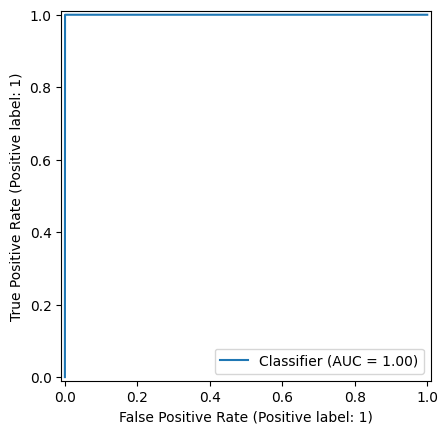

In [18]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred_score)

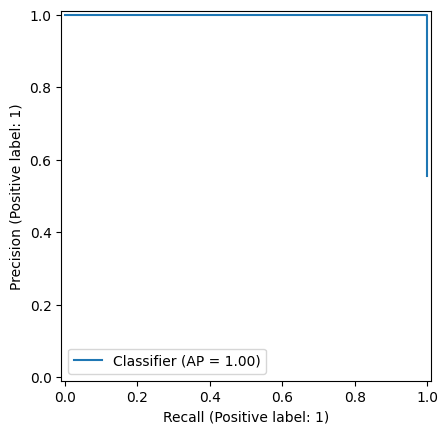

In [19]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_pred_score)

In [21]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
report = classification_report(y_test, Y_pred)
accuracy = accuracy_score(y_test, Y_pred)
print(report)
print(f'Accuracy: {accuracy}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5436
           1       1.00      1.00      1.00      6778

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg       1.00      1.00      1.00     12214

Accuracy: 0.9998362534796136


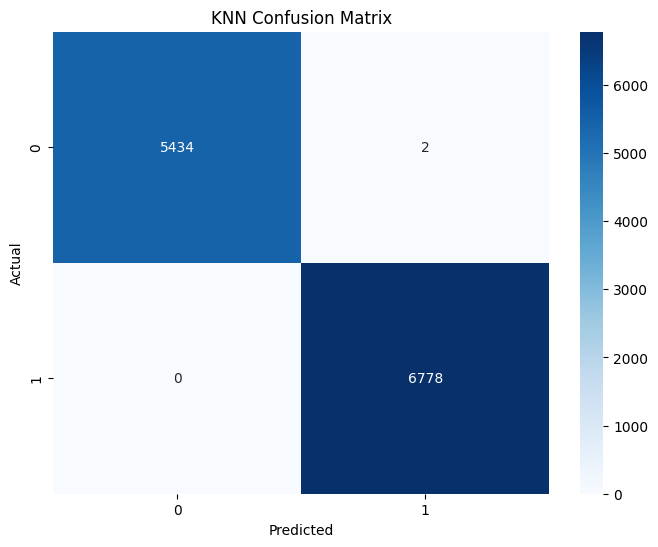

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('KNN Confusion Matrix')
plt.show()